In [3]:
import os
os.environ["KERAS_BACKEND"] = "torch"   # keras/tensorflow import 전에!

import keras, torch
print("backend :", keras.backend.backend())   # torch 나와야 GPU
print("cuda    :", torch.cuda.is_available())

backend : torch
cuda    : True


### 이미지 데이터 활용
- 실제 이미지 데이터를 가지고 모델에 학습을 진행
- 이미지 데이터는 그대로 사용할수 없고, 픽셀 단위로 나눠서 숫자로 변환하는 작업 필요
 - openCV에서 제공하는 read_img
 - tensorflow에서 제공하는 image_dataset_from_directory

In [4]:
# 데이터분석에 필요한 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 이미지를 수치화하기 위해 폴더에 접근하여 이미지를 읽어올수 있도록 도와주는 도구 불러오기
from tensorflow.keras.utils import image_dataset_from_directory

# 반복문을 사용할 때 진행상황을 보여주는 도구 불러오기
from tqdm import tqdm

In [5]:
train_img = image_dataset_from_directory(
    # 우리가 읽어올 데이터 경로
    directory='./data/animal/animal_small',
    # 정답데이터를 위해 폴더명을 그대로 정답으로 가져가도록 설정
    # 폴더명 -> 정수 라벨링
    labels='inferred',
    # 다중분류이기 때문에 원핫인코딩을 해야하는데 자동으로 해주도록 설정
    label_mode='categorical',
    # 색상채널 설정 (RGB의 컬러 이미지로 읽기)
    color_mode='rgb',
    # 이미지 사이즈 설정
    # 이미지 크기가 다를 경우에는 학습 할 수 없음 ->동일 크기 가지도록 설정!
    image_size=(224,224)
)

Found 2000 files belonging to 4 classes.


In [6]:
# 문제데이터(X), 정답데이터(y)를 분리하기 위해 직접 집어넣기
X_train = []
y_train = []

# train_img에서 배열값을 뽑아 
# 우리가 원하는 img데이터, label데이터를 추출해서 집어넣기
for img, label in train_img.as_numpy_iterator(): 
  X_train.append(img) 
  y_train.append(label)

In [7]:
# 리스트에 담겨있는 정보를 활용하여 배열형태로 넣기
X_train = np.concatenate(X_train)
y_train = np.concatenate(y_train)

In [6]:
# 데이터 크기 확인
X_train.shape, y_train.shape

((2000, 224, 224, 3), (2000, 4))

### MLP 층으로 인공신경망 설계(모델링)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, Flatten, Rescaling
from tensorflow.keras.optimizers import Adam

In [106]:
# 1. 신경망 구조 설계
# 뼈대 생성
model = Sequential()
# 입력층 - 입력데이터의 형태에 맞도록!  (224, 224, 3) : rgb라서 채널 3
model.add(InputLayer(shape=(224, 224, 3)))
# ★ 픽셀값 0~255 -> 0~1 스케일링 (주석 처리하면 학습이 거의 안 됨)
model.add(Rescaling(1./255))
# 1차원으로 평평하게 만들어주는 부분(flatten)
model.add(Flatten())
# 중간층 1 - 뉴런 64, 활성화함수 relu
model.add(Dense(64, activation='relu'))
# 중간층 2 - 뉴런 64, 활성화함수 relu
model.add(Dense(64, activation='relu'))
# 중간층 3 - 뉴런 64, 활성화함수 relu
model.add(Dense(64, activation='relu'))
# 출력층 - 다중분류(범주가 몇개인지) : cat/dog/sheep/squirrel -> 4개
model.add(Dense(units = 4, activation='softmax'))

# 2. 학습방법 및 평가방법 설정
# 다중분류 -> 손실함수 / 최적화함수 : adam / 평가지표 : 정확도
# ★ 'adam' 으로만 쓰면 기본 학습률 0.001이 적용되는데, 입력이 150528개나 되는
#    이 구조에선 너무 커서 첫 배치에 발산해버림(loss 12 고정, 정확도 25%).
#    반드시 Adam(learning_rate=0.0001) 형태로 낮춰서 써야 학습됨
model.compile(
    optimizer = Adam(learning_rate=0.0001),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_18 (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 64)             │     9,633,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,642,436 (36.78 MB)

 Trainable params: 9,642,436 (36.78 MB)

 Non-trainable params: 0 (0.00 B)

In [107]:
# 3. 학습
# epoch : 20, 검증용 데이터 - 훈련데이터의 2/10
# validation_split=0.2 -> 훈련데이터에서 20%를 검증용으로 떼어냄
h = model.fit(
    X_train, y_train,
    epochs = 20,
    validation_split = 0.2
)

Epoch 1/20
 3/50 ━━━━━━━━━━━━━━━━━━━━ 9s 198ms/step - accuracy: 0.2934 - loss: 1.6009 

KeyboardInterrupt: 

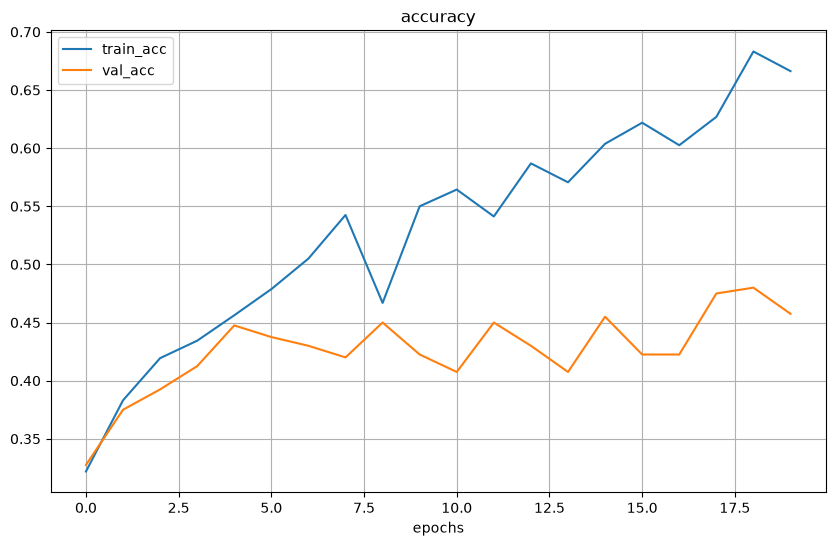

In [10]:
# 4. 결과 시각화
plt.figure(figsize=(10, 6))

# 정확도
plt.plot(h.history['accuracy'], label='train_acc')
plt.plot(h.history['val_accuracy'], label='val_acc')
plt.title('accuracy')
plt.xlabel('epochs')
plt.legend()
plt.grid(True)

plt.show()

---
# CNN (Convolutional Neural Network, 합성곱 신경망)

## 1. 왜 MLP로는 이미지가 잘 안 될까?
- `Flatten`으로 이미지를 1차원으로 펴는 순간 **픽셀의 위치 관계(공간 정보)가 완전히 파괴**됨
  - (224, 224, 3) → 150,528개의 그냥 나열된 숫자
  - "고양이 귀 옆에 눈이 있다" 같은 **이웃 픽셀 간의 관계**를 표현할 방법이 없음
- 파라미터가 폭발함 : 150,528 × 64 = **약 963만개** (첫 Dense 층 하나에서만!)
- 사진이 조금만 옮겨지거나(위치), 회전하거나(각도), 커지면(크기) → **완전히 다른 입력**으로 인식
  - 즉 MLP는 "왼쪽 위에 있는 고양이"와 "오른쪽 아래에 있는 고양이"를 따로 외워야 함

## 2. CNN의 핵심 아이디어
> 전체를 한 번에 보지 말고, **작은 창(필터)을 이미지 위에서 미끄러뜨리며** 특징을 찾자

| 구성 | 역할 |
|---|---|
| **Convolution (합성곱)** | 필터(커널)를 이미지 위에서 이동시키며 특징을 추출 (선/모서리/질감/눈/귀…) |
| **Pooling (풀링)** | 추출된 특징 중 **중요한 값만 남기고 크기를 줄임** → 연산량 ↓, 위치 변화에 둔감해짐 |
| **Flatten** | 특징추출이 끝난 3차원 특성맵을 1차원으로 펴서 분류부(MLP)로 전달 |

### CNN의 두 부분
```
[ 입력 이미지 ]
      ↓
┌─────────────────────────┐
│  특성추출부 (Feature Extraction)   │  ← Conv2D + MaxPooling2D 반복
│  "이 사진에 어떤 특징이 있는가?"      │
└─────────────────────────┘
      ↓  Flatten
┌─────────────────────────┐
│  분류부 (Classification)          │  ← Dense (MLP)
│  "그 특징들로 보아 무슨 동물인가?"    │
└─────────────────────────┘
      ↓
[ cat / dog / sheep / squirrel ]
```

## 3. 주요 하이퍼파라미터
| 파라미터 | 의미 | 비고 |
|---|---|---|
| `filters` | 필터(커널)의 **개수** = 뽑아낼 특징의 종류 수 | 출력 채널 수가 됨. 보통 층이 깊어질수록 늘림(32→64→128) |
| `kernel_size` | 필터의 **크기** (보통 (3,3)) | **홀수**로 설정 → 중심 픽셀이 존재해야 기준점이 생김 |
| `padding` | `'same'` : 가장자리에 0을 채워 **출력 크기 유지**<br>`'valid'` : 패딩 없음 → 출력 크기 줄어듦 | 가장자리에 정보가 많으면 `same` 유리, 대신 연산량 ↑ |
| `strides` | 필터를 **몇 칸씩** 건너뛰며 이동할지 | (2,2)면 출력 크기가 절반 → 다운샘플링 효과 |
| `pool_size` | 풀링 창의 크기 (기본 (2,2)) | (2,2)면 가로·세로 절반으로 축소 |

### 파라미터 개수 계산식
```
Conv2D 파라미터 = (커널높이 × 커널너비 × 입력채널 + 1(bias)) × 필터개수
예) 첫 Conv : (3 × 3 × 3 + 1) × 64 = 1,792개
```
> ★ 핵심 : **입력 이미지가 아무리 커도 Conv의 파라미터 수는 필터 크기에만 의존**
> → 이것이 CNN이 MLP보다 파라미터가 훨씬 적으면서도 성능이 좋은 이유 (가중치 공유)
---

In [9]:
# CNN 쌓기 위한 도구 불러오기
from tensorflow.keras.layers import Conv2D, MaxPooling2D

In [ ]:
# 1. 신경망 설계(CNN)
# 뼈대 생성
cnn_model = Sequential()

# ─────────────────────────────────────────────────────────────
# 입력층 : 한 장의 이미지 형태를 알려줌 (배치 크기는 적지 않음)
#   (224, 224, 3) = (높이, 너비, 색상채널)  ※ 채널 3 = RGB
# ─────────────────────────────────────────────────────────────
cnn_model.add(InputLayer(shape=(224,224,3)))

# ★ 픽셀값 0~255 -> 0~1 스케일링 (필수!)
#    이거 빼면 Conv 출력이 수백~수천으로 튀어서 첫 배치에 relu가 전부 죽고
#    loss 12 고정 / 정확도 25%(=1/4, 찍기 수준) 에서 안 움직임 (MLP 모델과 동일한 이유)
#    Rescaling을 '모델 안'에 넣는 이유 : X_train 원본을 건드리지 않아서
#    셀을 여러 번 실행해도 나누기가 중복 적용될 위험이 없음
cnn_model.add(Rescaling(1./255))

# ═══════════════ 특성추출부 (Feature Extraction) ═══════════════
# Conv : 특징(선, 모서리, 질감 등)을 추출하는 층
cnn_model.add(Conv2D(
    # 필터(커널)의 개수 = 뽑아낼 특징의 종류 수 -> 출력 채널 수가 됨
    filters=64,
    # 필터(커널)의 크기 조절 (무조건 홀수로 사용 -> 중심 픽셀이 존재해야 기준이 생김)
    kernel_size=(3,3),
    # 패딩 설정
    # 가장 자리에 중요한 정보가 들어있는 데이터의 경우 패딩 사용하는 것이 유리
    # 하지만 그렇지 않은경우 연산량 때문에 소모 자원이 많아져서 적절하게 사용
    padding='same', # same : 패딩 사용(크기 유지) / valid : 패딩 사용x(크기 감소)
    # 활성화 함수 : 음수를 0으로 만들어 비선형성 부여
    activation='relu'
))
# 출력 shape : (224, 224, 64)   / 파라미터 : (3*3*3 + 1) * 64 = 1,792

# Pooling : 정해진 창(2x2) 안에서 '가장 큰 값'만 남겨 중요한 특징만 걸러주는 층
#   - 크기가 절반으로 줄어 연산량 감소
#   - 특징이 조금 이동해도 같은 결과 -> 위치 변화에 강해짐 (이동 불변성)
#   - 학습되는 가중치가 없음 (파라미터 0개)
cnn_model.add(MaxPooling2D())
# 출력 shape : (112, 112, 64)   (기본 pool_size=(2,2) 라서 가로세로 1/2)

# Conv : 특징 추출하는 층 (두 번째 -> 앞 층이 찾은 특징들을 조합해 더 복잡한 특징을 찾음)
cnn_model.add(Conv2D(
    # 필터(커널)의 개수 설정
    filters=64,
    # 필터(커널)의 크기 조절 (무조건 홀수로 사용)
    kernel_size=(3,3),
    # 패딩 설정
    padding='same',
    # 활성화 함수
    activation='relu',
    # 스트라이드 - 몇 픽셀씩 건너 뛰면서 특징을 추출할건가요
    # (2,2) -> 두 칸씩 이동하므로 padding='same' 이어도 크기가 절반이 됨
    strides=(2,2)
))
# 출력 shape : (56, 56, 64)     / 파라미터 : (3*3*64 + 1) * 64 = 36,928

# Pooling : 중요한 특징만 걸러주는 층
cnn_model.add(MaxPooling2D(pool_size=(2,2)))
# 출력 shape : (28, 28, 64)

# ═══════════════ 연결부 ═══════════════
# Flatten : 3차원 특성맵 (28,28,64) 을 1차원 벡터로 펼침 -> 28*28*64 = 50,176
#   ※ 여기서 펼친 개수가 곧 다음 Dense 층 파라미터 수를 결정 -> 너무 크면 과대적합 위험
cnn_model.add(Flatten())

# ═══════════════ 분류부 (MLP) ═══════════════
# 중간층(은닉층) - 뉴런 개수 64개, 활성화함수 relu
cnn_model.add(Dense(units=64, activation='relu'))   # 50,176 * 64 + 64 = 3,211,328 (파라미터 대부분이 여기!)
cnn_model.add(Dense(units=64, activation='relu'))
cnn_model.add(Dense(units=64, activation='relu'))

# 출력층 : 클래스 개수(cat/dog/sheep/squirrel = 4)만큼 뉴런
#   softmax -> 4개 값의 합이 1인 '확률'로 변환 (다중분류)
cnn_model.add(Dense(units=4, activation='softmax'))

# 설계한 구조 / 층별 출력 shape / 파라미터 수 확인
cnn_model.summary()

# 정리 : MLP 963만개 -> CNN 326만개 로 파라미터는 오히려 줄었는데 성능은 좋아짐
#        (Conv는 필터 하나를 이미지 전체에 재사용하는 '가중치 공유' 구조이기 때문)

In [ ]:
# 2. 학습방법 및 평가방법 설정
# loss(손실함수) : 다중분류 + 정답이 원핫인코딩 -> categorical_crossentropy
#                 (정답이 0,1,2,3 같은 정수 라벨이면 sparse_categorical_crossentropy)
# ★ optimizer='adam' 은 기본 학습률 0.001 -> 이 구조에선 커서 발산함
#    MLP 때와 동일하게 Adam(learning_rate=0.0001) 로 낮춰서 사용
#    (학습률이 너무 크면 최저점을 지나쳐 튕겨나가고, 너무 작으면 학습이 느림)
cnn_model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0001),
    metrics=['accuracy']   # 사람이 보기 위한 평가지표 (학습에는 loss만 사용)
)

# 3. 학습 및 평가
#   validation_split=0.2 : 훈련데이터 2000장 중 20%(400장)를 검증용으로 떼어냄
#                          -> 실제 학습에 쓰이는 건 1600장
#   batch_size 기본값 32  -> 1600 / 32 = 50 step (진행바의 50/50 이 이것)
h_cnn = cnn_model.fit(
    X_train, y_train,
    epochs=20,
    validation_split=0.2
)

# 학습 결과 해석
#   train_acc 0.87  vs  val_acc 0.63  -> 격차 약 24%p = 과대적합(overfitting)
#   훈련 데이터는 계속 잘 맞추는데 처음 보는 데이터는 못 맞춤 = '외우고 있다'는 신호
#   원인 : 데이터가 2000장으로 적음 + Flatten 뒤 Dense 파라미터가 321만개로 너무 많음
#   해결책 : 데이터 증강 / Dropout / GlobalAveragePooling / 전이학습(아래에서 진행)

In [ ]:
# 학습 곡선 시각화
#   두 선이 붙어서 같이 올라가면 -> 학습이 잘 되는 중
#   train은 계속 오르는데 val이 정체/하락하면 -> 그 지점부터 과대적합 시작
plt.figure(figsize=(15,8))
plt.plot(h_cnn.history['accuracy'], label='cnn_acc')          # 훈련 정확도
plt.plot(h_cnn.history['val_accuracy'], label='val_acc')      # 검증 정확도
plt.legend()
plt.grid(True)
plt.show()

### 결과 확인 : MLP vs CNN

| 모델 | 파라미터 수 | train_acc | val_acc | 비고 |
|---|---|---|---|---|
| MLP (Dense만) | 약 964만개 | 낮음 | 낮음 | 공간 정보 소실, 학습 자체가 느리고 불안정 |
| **CNN** | 약 326만개 | 0.87 | **0.63** | 파라미터는 더 적은데 성능은 더 좋음 |

- 일반적인 MLP 층을 사용했을 때보다 성능 개선
- 이미지 데이터 같은 경우 비슷한 형태나 방향, 각도, 위치 등을 맞추기 어렵기 때문에 CNN층과 같이 특성을 추출할 수 있는 방법을 사용

#### 남은 문제 : 과대적합(Overfitting)
- train 0.87 / val 0.63 → **약 24%p 격차** = 훈련 데이터를 "외우고" 있음
- 원인
  1. 데이터가 2,000장으로 **너무 적음** (딥러닝 기준으로 매우 소량)
  2. `Flatten` 뒤 Dense 층 파라미터가 **321만개**로 과도하게 큼
- 해결 방향
  - 데이터 증강(Augmentation) : 뒤집기/회전 등으로 데이터를 늘린 효과
  - Dropout : 학습 중 뉴런 일부를 랜덤으로 꺼서 특정 경로 의존을 막음
  - `GlobalAveragePooling2D` : Flatten 대신 사용해 파라미터를 극단적으로 줄임
  - ★ **전이학습(Transfer Learning)** : 남이 대량 데이터로 학습해 둔 모델을 빌려 쓰기

### 실습 : CNN 알고리즘을 활용해서 동물 분류 실습
- 내가 직접 CNN층을 이용하여 모델 설계


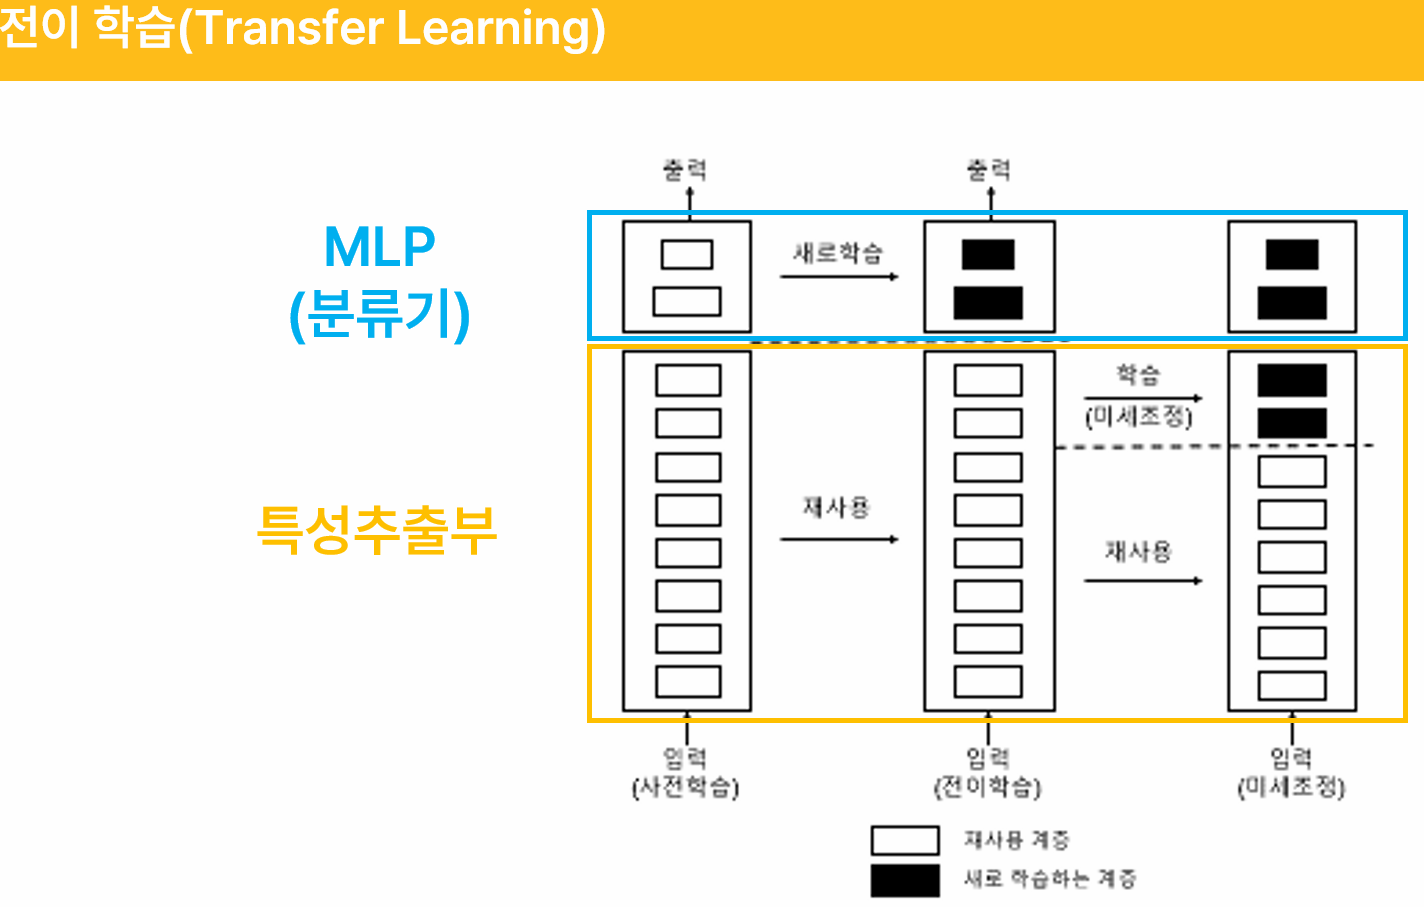

---
# 전이학습 (Transfer Learning)

## 1. 왜 필요한가?
- 우리가 가진 데이터는 **2,000장** → 밑바닥부터 학습시키기엔 절대적으로 부족
- 반면 세상에는 **ImageNet(1,400만장 / 1,000개 클래스)** 같은 거대 데이터로 이미 학습된 모델이 공개되어 있음
- 그 모델의 **특성추출부(CNN층)** 는 이미 "선, 모서리, 질감, 눈, 털, 다리…" 를 뽑는 법을 알고 있음
> 남이 오랜 시간 학습해 둔 **"보는 눈"** 을 빌려오고, 나는 **"판단하는 법"** 만 학습하자

## 2. 두 가지 방식

### ① 특성추출방식 (Feature Extraction)
```
[사전학습 CNN층]  ← 전부 동결(freeze), 학습 안 함
        ↓
[ 내 MLP 분류부 ]  ← 이것만 새로 학습
```
- 가장 빠르고 데이터가 적을 때 안전
- 내 데이터가 사전학습 데이터와 **성격이 비슷할 때** 효과적

### ② 미세조정방식 (Fine Tuning)
```
[사전학습 CNN층 앞부분]  ← 동결 (일반적인 특징 : 선, 모서리)
[사전학습 CNN층 뒷부분]  ← 동결 해제, 아주 작은 학습률로 재학습 (구체적 특징)
        ↓
[ 내 MLP 분류부 ]        ← 새로 학습
```
- 내 데이터가 사전학습 데이터와 **다소 다를 때** 성능을 더 끌어올릴 수 있음
- 반드시 **분류부를 먼저 학습시킨 뒤**, 아주 낮은 학습률(1e-5 수준)로 진행
  - 안 그러면 초기 랜덤 가중치가 만든 큰 오차가 사전학습 가중치를 망가뜨림

## 3. 동결(Freeze)의 개념
| 설정 | 의미 |
|---|---|
| `model.trainable = False` | 역전파 시 **가중치를 갱신하지 않음** = 지식 보존 |
| `model.trainable = True` | 내 데이터에 맞게 가중치가 변함 |
> 동결하지 않으면, 랜덤 초기화된 분류부에서 나온 큰 오차가 CNN층까지 흘러들어가
> **1,400만장으로 학습한 지식을 2,000장이 덮어써 버림** → 모델을 빌려온 의미가 사라짐
---

### 특성추출방식(Feature Extraction)
- CNN층의 특성추출부 전체를 가져와서 사용하는 방식
- 분류부(MLP층)만 내 데이터에 맞도록 다시 설계하여 사용하는 방법
- 사전학습된 데이터와 내가 학습할 데이터의 특징이 어느정도 맞아야 좋은 성능을 기대할 수 있음
- 만약에 사전학습된 데이터의 특징이 너무나 다를 경우에는 CNN층을 그대로 사용했을 때 원하는 성능이 안 나올 수 있음

### 미세조정방식(Fine Tunning)
- 기존에 학습된 모델을 기반으로, 내 데이터에 맞도록 가중치 일부를 미세하게 조정하는 방식으로 내 데이터에 최대한 잘 반응하도록 학습하는 방식
- CNN층의 일부분을 나의 데이터셋에 맞도록 새로 학습시켜 사용하는 방법

### 목표
- CNN모델을 사용해서 분류했던 동물데이터를 가지고 전이학습을 하여 성능 개선을 해보자
- 특성추출방식과 미세조정방식을 모두 사용하면서 전이학습을 진행해보자


### VGG16 모델 사용
- CNN 아키텍처를 획기적인 객체 인식 모델을 기반으로 하여 ImageNet이라는 방대한 데이터셋을 가지고 높은 정확도를 보이는 모델
- 13개 Convolution Layer와 3개의 Fully Connected Layer로 구성된 모델
- 모든 Convolution Layer의 커널의 크기는 (3,3)으로 되어 있으며, activation은 relu를 사용한 모델
- 입력 이미지를 사용할 때 (224,224,3)으로 되어 있는 컬러 이미지를 사용한 모델

In [10]:
from tensorflow.keras.applications import VGG16

In [ ]:
vgg16 = VGG16(
    # MLP층(분류부)을 사용하지 않도록 설정 (특성추출부만 가지고 올 것)
    #  - True  : ImageNet 1000개 클래스용 분류부까지 포함 -> 우리 문제(4개)에 못 씀
    #  - False : Conv/Pooling 층만 가져옴 -> 분류부는 내가 새로 붙임
    include_top=False,
    # 가중치(w) 설정 (imagenet으로 학습되었던 가중치 불러오기)
    #  - None 으로 두면 '구조만' 가져오고 가중치는 랜덤 -> 전이학습이 아님
    weights='imagenet',
    # 입력데이터 설정 (VGG16이 원래 학습했던 크기와 동일하게 맞춰줌)
    input_shape=(224, 224, 3)
)

# vgg16의 출력 shape : (7, 7, 512)
#   224 -> 112 -> 56 -> 28 -> 14 -> 7  (MaxPooling 5번으로 1/32)
#   채널은 64 -> 128 -> 256 -> 512 -> 512 로 깊어짐
#   (앞쪽 층 = 선/모서리 같은 일반적 특징, 뒤쪽 층 = 눈/털 같은 구체적 특징)
vgg16.summary()

### 동결설정
- 우리가 가져온 CNN층은 ImageNet이라는 거대 데이터를 가지고 학습한 모델이다.
- 그런데 우리 데이터가 CNN층을 지나갈 때 학습이 일어나버리면 거대 데이터셋으로 학습된 정보가 사라지기 때문에 모델을 가져와 사용하는 의미가 없어져 버린다.
- 이런 일이 일어나지 않도록 데이터가 CNN층을 지나갈 때 추가적인 학습이 일어나지 않도록 설정하는 것이 동결설정이다. (가중치가 변화되지 않도록 설정)
  - trainable(학습여부)=False 설정

In [ ]:
# 동결설정 : VGG16 안의 모든 층의 가중치를 '학습되지 않도록' 잠금
#   -> summary()에서 Trainable params 는 0, Non-trainable params 에 1,471만개로 잡힘
#   -> 학습 속도도 빨라짐 (역전파 계산을 CNN층에서 안 하므로)
vgg16.trainable = False

In [13]:
# 신경망 설계를 위한 도구 불러오기
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, Flatten, Conv2D, MaxPooling2D, Dropout, BatchNormalization, Activation

In [ ]:
# 1. 신경망 구조 설계
# 전이학습(특성추출방식) - 개선판
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import Lambda, GlobalAveragePooling2D, RandomFlip
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 뼈대생성
transfer_model = Sequential()

# 입력층
transfer_model.add(InputLayer(shape=(224, 224, 3)))

# [개선3] VGG16 전용 전처리
#  VGG16은 0~1 스케일링이 아니라 'RGB->BGR 변환 + 채널별 평균 빼기' 방식으로 학습됨.
#  0~255 원본을 그대로 넣으면 미묘하게 어긋난 상태로 특징을 뽑게 됨.
#  ※ 사전학습 모델은 '그 모델이 학습할 때 썼던 전처리'를 그대로 맞춰줘야 성능이 나옴
#  Lambda로 모델 안에 넣으면 X_train 자체를 건드리지 않으므로
#  셀을 여러 번 실행해도 전처리가 중복 적용될 위험이 없음.
transfer_model.add(Lambda(preprocess_input))

# 데이터 증강 : 좌우 뒤집기 (텐서를 뒤집기만 하므로 거의 공짜)
#  ※ 학습(fit) 중에만 동작하고, 평가/예측(predict) 때는 자동으로 꺼짐
#  같은 사진을 매 epoch 다르게 보여줘서 '외우기'를 방해 -> 과대적합 완화
transfer_model.add(RandomFlip('horizontal'))

# 특성추출부(CNN) -> VGG16 (동결되어 있어 학습되지 않음)
#  Sequential 안에 '모델 하나를 통째로 층처럼' 넣을 수 있음
transfer_model.add(vgg16)          # 출력 : (7, 7, 512)

# [개선1] Flatten -> GlobalAveragePooling2D
#  Flatten은 7x7x512 = 25088개를 펼쳐서 Dense(64)로 보냄 -> 파라미터 160만개.
#  이 160만개가 훈련데이터 1600장을 통째로 외워서 train_acc를 100%로 만든 주범.
#  GAP는 채널마다 7x7 평균을 내서 512개로 압축 -> 파라미터 0개.
#  (7,7,512) -> (512,)  "각 특징이 이미지 전체에서 평균적으로 얼마나 강했나"만 남김
transfer_model.add(GlobalAveragePooling2D())

# ═══════════════ 분류부(MLP) ═══════════════
# [개선2] Dense 순서를 넓 -> 좁 으로 정리하고 Dropout 추가
#  기존 64 -> 128 -> 64 는 64로 압축한 정보를 128로 다시 늘리는 구조라 낭비였음
#  Dropout(0.5) : 학습할 때마다 뉴런의 50%를 랜덤으로 꺼서
#                 특정 뉴런에만 의존하지 못하게 함 -> 과대적합 억제
transfer_model.add(Dropout(0.5))
transfer_model.add(Dense(256, activation='relu'))
transfer_model.add(Dropout(0.3))

# 출력층 : 클래스 4개 + softmax
transfer_model.add(Dense(units=4, activation='softmax'))

transfer_model.summary()
# Trainable params 약 13만개 / Non-trainable params 약 1,471만개 인지 확인!
#  -> Trainable에 1400만이 잡혀 있으면 동결(vgg16.trainable=False)이 안 된 것

# 2. 학습방법 및 평가방법 설정
# 학습되는 건 분류부(약 13만개)뿐이라 학습률을 0.001로 써도 안정적
transfer_model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# 3. 콜백(Callback) : 학습 도중 자동으로 개입해주는 도구
# val_accuracy가 최고였던 시점의 가중치를 학습 종료 후 자동 복원
#  -> 그래프에서 최고점을 눈으로 읽는 게 아니라, 그 모델을 실제로 갖게 됨
#  patience=8 : 8 epoch 동안 개선이 없으면 학습 중단
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True,   # ★ 이게 없으면 '가장 나빠진 마지막 상태'로 끝남
    verbose=1
)
# 성능이 정체되면 학습률을 절반으로 낮춰 더 미세하게 최적점 탐색
#  (보폭이 커서 최저점 주변을 왔다갔다 할 때 보폭을 줄여주는 역할)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,      # 학습률 x 0.5
    patience=4,      # 4 epoch 동안 val_loss 개선 없으면 발동
    min_lr=1e-6,     # 이 아래로는 안 내림
    verbose=1
)

# 4. 학습
h_transfer = transfer_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr]   # 만들어 둔 콜백을 리스트로 전달
)

In [ ]:
# 시각화
#  전이학습 후 확인 포인트
#   1) 1 epoch 만에 val_acc가 훌쩍 뛰는가 -> VGG16이 이미 좋은 특징을 뽑아준다는 증거
#   2) train선과 val선의 '간격'이 CNN 때(24%p)보다 줄었는가 -> 과대적합 완화 확인
plt.figure(figsize=(15,8))
plt.plot(h_transfer.history['accuracy'], label='cnn_acc')
plt.plot(h_transfer.history['val_accuracy'], label='cnn_val_acc')
plt.legend()
plt.grid(True)
plt.show()

---
# ex04 총정리

## 성능 흐름
```
MLP (Dense만)         →   CNN 직접 설계        →   전이학습(VGG16)
공간 정보 소실             과대적합 (0.87/0.63)      사전학습 특징 재사용
파라미터 964만개           파라미터 326만개          학습 파라미터 13만개
```

## 오늘 배운 핵심 개념 체크리스트
- [x] `Conv2D` : filters / kernel_size / padding / strides 의 의미
- [x] `MaxPooling2D` : 중요한 값만 남기고 크기 축소, 파라미터 0개
- [x] **가중치 공유** : 입력이 커도 파라미터가 늘지 않는 이유
- [x] **Rescaling(1./255)** 없이는 학습 자체가 시작되지 않음 (loss 고정 / acc 25%)
- [x] **learning_rate** : Adam 기본값 0.001이 항상 정답은 아님 (발산 시 0.0001로)
- [x] **과대적합** 판단법 : train_acc와 val_acc의 **격차**를 볼 것
- [x] **전이학습** : 특성추출방식 vs 미세조정방식
- [x] **동결(`trainable=False`)** 의 이유
- [x] 사전학습 모델은 **그 모델 전용 `preprocess_input`** 을 써야 함
- [x] `GlobalAveragePooling2D` 로 Flatten의 파라미터 폭발 회피
- [x] `Dropout` / `RandomFlip`(증강) 으로 과대적합 억제
- [x] 콜백 : `EarlyStopping(restore_best_weights=True)`, `ReduceLROnPlateau`

## 참고 : 미세조정(Fine Tuning) 진행 시 코드 형태
```python
# 1단계 : 위에서 한 것처럼 분류부만 먼저 충분히 학습시킨다 (필수!)

# 2단계 : VGG16 동결을 풀고, 뒷부분 층만 다시 잠근 채로 재학습
vgg16.trainable = True
for layer in vgg16.layers[:-4]:      # 마지막 4개 층만 학습 대상으로 남김
    layer.trainable = False

# 3단계 : 반드시 아주 낮은 학습률로 다시 compile
transfer_model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=1e-5),   # ★ 0.001로 하면 사전학습 가중치가 망가짐
    metrics=['accuracy']
)
transfer_model.fit(X_train, y_train, epochs=10, validation_split=0.2)
```
> ⚠️ 주의 : 분류부를 학습시키기 전에 미세조정부터 하면,
> 랜덤 초기화된 분류부의 큰 오차가 CNN층으로 역전파되어 **사전학습 지식이 파괴됨**
---